Loading sample of size: [5000, 5000]
Resetting stage position to center position
Acquiring image...


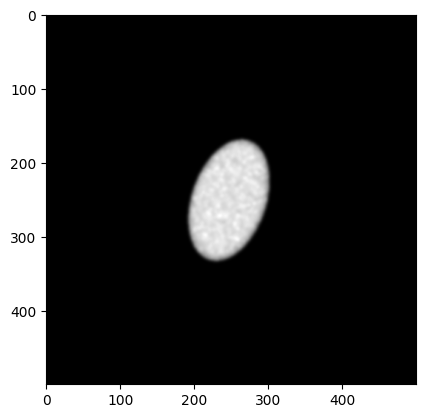

In [4]:
import math
from matplotlib import pyplot as plt
from microscopai_sandbox import MicroscopAIsandbox
from microscopai_sandbox.samples.ellipsoid import Ellipsoid

microscope = MicroscopAIsandbox(fov_size=[500, 500])
sample = Ellipsoid(
    sample_size=microscope.stage_size,
    bleaching_rate=0.05,
    n_objects=20,
    movement_rate=5,
    movement_probability=0.7,
    axis_deformation_probability=0.7,
    axis_deformation_rate=0.1,
    rotation=math.pi*0.5,
    rotation_probability=0.7,
    mode="Full",
)
microscope.set_laser_power(100)
frame = microscope.load_sample(sample, acquire=True)
plt.imshow(frame, vmin=0, cmap="gray")

Stage Moved to position: [2550, 2550]. Acquiring image...


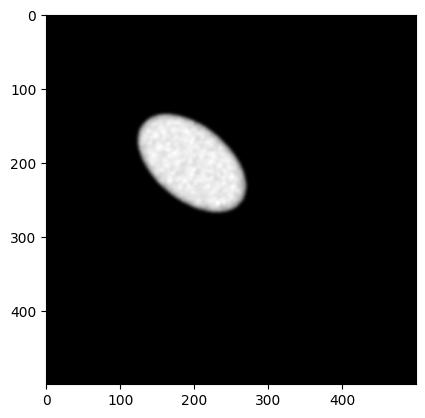

In [5]:
new_frame = microscope.move_stage([50, 50], acquire=True)
plt.imshow(new_frame, vmin=0, cmap="gray")

In [7]:
import numpy as np

stack = np.zeros((100, 500, 500)).astype(np.float32)

for i in range(100):
    frame = microscope.acquire_image()
    stack[i] = frame

In [8]:
import tifffile

tifffile.imwrite("test_stack.tif", stack)